In [2]:
import polars as pl
import scipy.sparse as sp
import numpy as np
import joblib
import os

# --- 1. LOAD THE CLEANED DATA ONLY ---
# We use the 'final' version we just created!
data_path = "data/processed/ratings_final.parquet" 

print(f"--- Loading Filtered Data from: {data_path} ---")
df = pl.read_parquet(data_path)

# --- 2. Create Mappings ---
# We need to map real IDs (like 163668) to matrix indices (0, 1, 2...)
print("--- Creating Mappings ---")
user_ids = df["userId"].unique().sort()
movie_ids = df["movieId"].unique().sort()

user_to_index = {user: i for i, user in enumerate(user_ids)}
movie_to_index = {movie: i for i, movie in enumerate(movie_ids)}

# SAVE THESE - You will need them for the prediction app!
joblib.dump(user_to_index, "user_map.pkl")
joblib.dump(movie_to_index, "movie_map.pkl")
print(f"Mappings saved. Users: {len(user_ids)}, Movies: {len(movie_ids)}")

# --- 3. Build the Interaction Matrix ---
print("--- Building Interaction Matrix (This may take a minute) ---")

# Replace real IDs with our new 0-indexed positions
df = df.with_columns([
    pl.col("userId").replace(user_to_index).alias("user_idx"),
    pl.col("movieId").replace(movie_to_index).alias("movie_idx")
])

# Convert to numpy for Scipy
rows = df["user_idx"].to_numpy()
cols = df["movie_idx"].to_numpy()
data = df["rating"].to_numpy().astype(np.float32)

# Create the sparse matrix (COO format is fastest for building)
interaction_matrix = sp.coo_matrix(
    (data, (rows, cols)), 
    shape=(len(user_ids), len(movie_ids))
)

# Convert to CSR format (Faster for the AI to actually read)
interaction_matrix = interaction_matrix.tocsr()

print("--- SUCCESS ---")
print(f"Matrix Shape: {interaction_matrix.shape} (Users x Movies)")

--- Loading Filtered Data from: data/processed/ratings_final.parquet ---
--- Creating Mappings ---
Mappings saved. Users: 200948, Movies: 43884
--- Building Interaction Matrix (This may take a minute) ---
--- SUCCESS ---
Matrix Shape: (200948, 43884) (Users x Movies)


In [ ]:
import polars as pl
import os
# --- LOAD THE PROCESSED DATA FILES ---
processed_ratings = "data/processed/ratings_final.parquet"
processed_movies = "data/processed/movies_final.parquet"

df_ratings = pl.read_parquet(processed_ratings)
df_movies = pl.read_parquet(processed_movies)

print(df_ratings.head(5))
print(df_movies.head(5))


--- RATINGS: 31921467 ROWS ---
shape: (5, 3)
┌────────┬─────────┬────────┐
│ userId ┆ movieId ┆ rating │
│ ---    ┆ ---     ┆ ---    │
│ i64    ┆ i64     ┆ f64    │
╞════════╪═════════╪════════╡
│ 1      ┆ 17      ┆ 4.0    │
│ 1      ┆ 25      ┆ 1.0    │
│ 1      ┆ 29      ┆ 2.0    │
│ 1      ┆ 30      ┆ 5.0    │
│ 1      ┆ 32      ┆ 5.0    │
└────────┴─────────┴────────┘

--- MOVIES: 43884 ROWS ---
shape: (5, 6)
┌─────────┬────────────────────┬──────┬────────────────────┬───────────────────┬───────────────────┐
│ movieId ┆ genres             ┆ year ┆ title              ┆ tag               ┆ display_title     │
│ ---     ┆ ---                ┆ ---  ┆ ---                ┆ ---               ┆ ---               │
│ i64     ┆ str                ┆ i32  ┆ str                ┆ str               ┆ str               │
╞═════════╪════════════════════╪══════╪════════════════════╪═══════════════════╪═══════════════════╡
│ 285757  ┆ Action             ┆ 2023 ┆ Supercell          ┆ tornado          

In [ ]:
import polars as pl

# Load the CLEANED files we just saved
movies_df = pl.read_parquet("data/processed/movies_final.parquet")
ratings_df = pl.read_parquet("data/processed/ratings_final.parquet")

print(f"Nulls in Movies:\n{movies_df.null_count()}")

--- STATUS CHECK ---
Movies: 43884 (Should be 43,884)
Ratings: 31921467 (Should be 31,921,467)
Nulls in Movies:
shape: (1, 6)
┌─────────┬────────┬──────┬───────┬─────┬───────────────┐
│ movieId ┆ genres ┆ year ┆ title ┆ tag ┆ display_title │
│ ---     ┆ ---    ┆ ---  ┆ ---   ┆ --- ┆ ---           │
│ u32     ┆ u32    ┆ u32  ┆ u32   ┆ u32 ┆ u32           │
╞═════════╪════════╪══════╪═══════╪═════╪═══════════════╡
│ 0       ┆ 0      ┆ 0    ┆ 0     ┆ 0   ┆ 0             │
└─────────┴────────┴──────┴───────┴─────┴───────────────┘


In [ ]:
import polars as pl
import os

tags_path = os.path.join("data", "raw", "tags.csv")
tags_df = (
    pl.read_csv(tags_path)
    .select(["movieId", "tag"])
    .drop_nulls()
    .with_columns(pl.col("tag").str.to_lowercase())
    .group_by("movieId")
    .agg(pl.col("tag").str.join(" "))
)

movies_df = movies_df.join(tags_df, on="movieId", how="left")
movies_df = movies_df.with_columns(pl.col("tag").fill_null(""))

print(f"Movies with tags: {movies_df.filter(pl.col('tag') != '').height} out of {movies_df.height}")
print(f"Columns now: {movies_df.columns}")

--- REPAIR SUCCESSFUL ---
Movies with tags: 35231 out of 43884
Columns now: ['movieId', 'genres', 'year', 'title', 'tag', 'display_title', 'tag_right']


In [ ]:
import polars as pl
import os
PATH_RATINGS_FINAL = os.path.join("data", "processed", "ratings_final.parquet")
ratings_df = pl.read_parquet(PATH_RATINGS_FINAL)

user_counts = ratings_df.group_by("userId").len().sort("len")
movie_counts = ratings_df.group_by("movieId").len().sort("len")

print("--- USER ACTIVITY STATS ---")
print(f"Total Users: {len(user_counts)}")
print(f"Users with only 1 rating: {user_counts.filter(pl.col('len') == 1).height}")
print(f"Average ratings per user: {user_counts['len'].mean():.2f}")

print("\n--- MOVIE POPULARITY STATS ---")
print(f"Total Movies: {len(movie_counts)}")
print(f"Movies with only 1 rating: {movie_counts.filter(pl.col('len') == 1).height}")

--- USER ACTIVITY STATS ---
Total Users: 200948
Users with only 1 rating: 0
Average ratings per user: 158.85

--- MOVIE POPULARITY STATS ---
Total Movies: 43884
Movies with only 1 rating: 0


In [ ]:
movie_counts = ratings_df.group_by("movieId").len()
keep_ids = movie_counts.filter(pl.col("len") >= 5).select("movieId")

print(f"Number of movies that have 5+ ratings: {keep_ids.height}")

Number of movies that have 5+ ratings: 43884


In [ ]:
movies_df = pl.read_parquet("data/processed/movies_final.parquet")
movies_df = movies_df.join(keep_ids, on="movieId", how="inner")

# Drop the 1 row where title_clean is missing
movies_df = movies_df.drop_nulls(subset=["title_clean"])

print(f"Final Movie Count: {movies_df.height}")

ColumnNotFoundError: "title_clean" not found

In [ ]:
ratings_df = ratings_df.join(keep_ids, on="movieId", how="inner")

print(f"Movies saved: {movies_df.height} rows")
print(f"Ratings saved: {ratings_df.height} rows")

--- FILES UPDATED ON DISK ---
Movies saved: 43884 rows
Ratings saved: 31921467 rows


In [ ]:
import polars as pl
import os

movies_df = pl.read_parquet("data/processed/movies_final.parquet")
ratings_df = pl.read_parquet("data/processed/ratings_final.parquet")
tags_path = os.path.join("data", "raw", "tags.csv")

# 2. PROCESS TAGS
# We process tags and join them immediately to movies_df
tags_df = (
    pl.scan_csv(tags_path)
    .select(["movieId", "tag"])
    .drop_nulls()
    .with_columns(pl.col("tag").str.to_lowercase())
    .group_by("movieId")
    .agg(pl.col("tag").str.join(" "))
    .collect()
)

movies_df = movies_df.join(tags_df, on="movieId", how="left").with_columns(
    pl.col("tag").fill_null("")
)

# 3. DEFINE THE KEEP_IDS (Sanity Check)
movie_counts = ratings_df.group_by("movieId").len()
keep_ids = movie_counts.filter(pl.col("len") >= 5).select("movieId")

# 4. FINAL FILTER & SAVE
# This ensures both files are perfectly synced at 43,884 movies
movies_df = movies_df.join(keep_ids, on="movieId", how="inner")
ratings_df = ratings_df.join(keep_ids, on="movieId", how="inner")

# Overwrite the clean files with the NEW column included
movies_df.write_parquet("data/processed/movies_final.parquet")
ratings_df.write_parquet("data/processed/ratings_final.parquet")

print("\n--- SYSTEM RECOVERED & FILES UPDATED ---")
print(f"Movies: {movies_df.height} | Ratings: {ratings_df.height}")
print(f"Columns: {movies_df.columns}")

Loading data...

--- SYSTEM RECOVERED & FILES UPDATED ---
Movies: 43884 | Ratings: 31921467
Columns: ['movieId', 'genres', 'year', 'title', 'tag', 'display_title', 'tag_right']


In [ ]:
if "tag_right" in movies_df.columns:
    movies_df = movies_df.drop("tag_right")

# 2. Get Unique Genres
unique_genres = (
    movies_df.select("genres")
    .with_columns(pl.col("genres").str.split("|"))
    .explode("genres")
    .unique()
    .sort("genres")
)["genres"].to_list()

if "(no genres listed)" in unique_genres: unique_genres.remove("(no genres listed)")

for genre in unique_genres:
    col_name = f"g_{genre.lower().replace(' ', '_').replace('-', '_')}"
    movies_df = movies_df.with_columns(
        pl.col("genres").str.contains(genre).cast(pl.Int8).alias(col_name)
    )

min_y = movies_df.filter(pl.col("year") > 0)["year"].min()
max_y = movies_df["year"].max()
movies_df = movies_df.with_columns(
    ((pl.col("year") - min_y) / (max_y - min_y)).clip(0, 1).alias("year_scaled")
)

movies_df.write_parquet("data/processed/movies_featurized.parquet")

print("--- FEATURE ENGINEERING COMPLETE ---")
print(f"New Columns: {[c for c in movies_df.columns if c.startswith('g_') or c == 'year_scaled']}")
print(f"Final Table saved to: data/processed/movies_featurized.parquet")

--- FEATURE ENGINEERING COMPLETE ---
New Columns: ['g_action', 'g_adventure', 'g_animation', 'g_children', 'g_comedy', 'g_crime', 'g_documentary', 'g_drama', 'g_fantasy', 'g_film_noir', 'g_horror', 'g_imax', 'g_musical', 'g_mystery', 'g_romance', 'g_sci_fi', 'g_thriller', 'g_war', 'g_western', 'year_scaled']
Final Table saved to: data/processed/movies_featurized.parquet


In [13]:
# Kill the redundant tag_right column
if "tag_right" in movies_df.columns:
    movies_df = movies_df.drop("tag_right")

# Verify it's gone
print("Remaining Columns:")
print(movies_df.columns)

Remaining Columns:
['movieId', 'genres', 'year', 'title', 'tag', 'display_title', 'g_action', 'g_adventure', 'g_animation', 'g_children', 'g_comedy', 'g_crime', 'g_documentary', 'g_drama', 'g_fantasy', 'g_film_noir', 'g_horror', 'g_imax', 'g_musical', 'g_mystery', 'g_romance', 'g_sci_fi', 'g_thriller', 'g_war', 'g_western', 'year_scaled']


In [41]:
# 1. Drop the original messy 'title'
movies_df = movies_df.drop("title")

# 2. Rename 'title_clean' to 'title' so it looks normal
movies_df = movies_df.rename({"title_clean": "title"})

movies_df.write_parquet("data/processed/movies_final.parquet")

print(f"Current Columns: {movies_df.columns}")
print(movies_df.select(["movieId", "title", "year"]).head(5))

ColumnNotFoundError: "title" not found

In [42]:
# 1. See all unique titles as a list (first 20)
print("--- FIRST 20 UNIQUE TITLES ---")
print(movies_df.select("title_clean").unique().head(20))

# 2. THE HELPFUL SHIT: See if any titles are duplicates
# (This shows you titles that appear in the list more than once)
duplicates = (
    movies_df.group_by("title")
    .len()
    .filter(pl.col("len") > 1)
    .sort("len", descending=True)
)

print("\n--- DUPLICATED TITLES (Movies with the same name) ---")
print(duplicates.head(10))

--- FIRST 20 UNIQUE TITLES ---


ColumnNotFoundError: unable to find column "title_clean"; valid columns: ["movieId", "genres", "year", "tag", "display_title", "g_action", "g_adventure", "g_animation", "g_children", "g_comedy", "g_crime", "g_documentary", "g_drama", "g_fantasy", "g_film_noir", "g_horror", "g_imax", "g_musical", "g_mystery", "g_romance", "g_sci_fi", "g_thriller", "g_war", "g_western", "year_scaled"]

In [ ]:
# 1. Create a unique display title by combining title and year
# This turns "Cinderella" into "Cinderella (1950)"
movies_df = movies_df.with_columns(
    (pl.col("title") + " (" + pl.col("year").cast(pl.Utf8) + ")").alias("display_title")
)

# 2. Check for duplicates again on this NEW column
final_dupes = (
    movies_df.group_by("display_title")
    .len()
    .filter(pl.col("len") > 1)
)

print(f"Duplicate 'display_titles' remaining: {final_dupes.height}")
print("--- TITLES ARE NOW UNIQUE ---")
print(movies_df.select(["display_title", "genres"]).head(5))

ColumnNotFoundError: unable to find column "title"; valid columns: ["movieId", "genres", "year", "tag", "display_title", "g_action", "g_adventure", "g_animation", "g_children", "g_comedy", "g_crime", "g_documentary", "g_drama", "g_fantasy", "g_film_noir", "g_horror", "g_imax", "g_musical", "g_mystery", "g_romance", "g_sci_fi", "g_thriller", "g_war", "g_western", "year_scaled"]

In [17]:
# THE FINAL LOCK-IN
# 1. Update the saved files with the 'display_title' and cleaned columns
movies_df.write_parquet("data/processed/movies_final.parquet")
ratings_df.write_parquet("data/processed/ratings_final.parquet")

print("--- FILES SAVED TO DISK FOREVER ---")
print(f"Final Movies: {movies_df.height} (with unique display_titles)")
print(f"Final Ratings: {ratings_df.height}")
print(f"Columns in movies_final: {movies_df.columns}")

--- FILES SAVED TO DISK FOREVER ---
Final Movies: 43884 (with unique display_titles)
Final Ratings: 31921467
Columns in movies_final: ['movieId', 'genres', 'year', 'tag', 'display_title', 'g_action', 'g_adventure', 'g_animation', 'g_children', 'g_comedy', 'g_crime', 'g_documentary', 'g_drama', 'g_fantasy', 'g_film_noir', 'g_horror', 'g_imax', 'g_musical', 'g_mystery', 'g_romance', 'g_sci_fi', 'g_thriller', 'g_war', 'g_western', 'year_scaled']


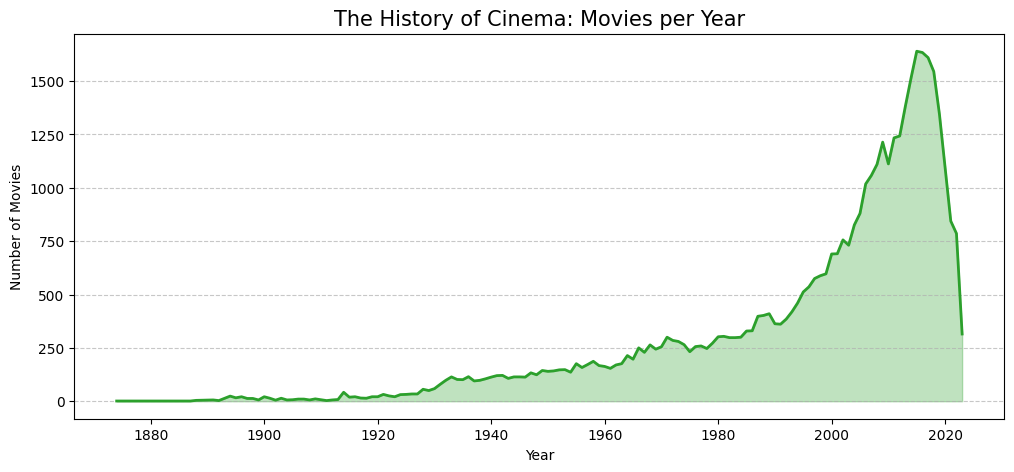

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- VISUAL 1: MOVIE TIMELINE ---
# How many movies were released each year?
plt.figure(figsize=(12, 5))
year_counts = movies_df.filter(pl.col("year") > 0).group_by("year").len().sort("year")
plt.plot(year_counts["year"], year_counts["len"], color='#2ca02c', linewidth=2)
plt.fill_between(year_counts["year"], year_counts["len"], alpha=0.3, color='#2ca02c')
plt.title("The History of Cinema: Movies per Year", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("movie_timeline.png")


C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\2472834855.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="len", y="genres", data=genre_counts.to_pandas(), palette="viridis")


Text(0.5, 0, 'Number of Movies')

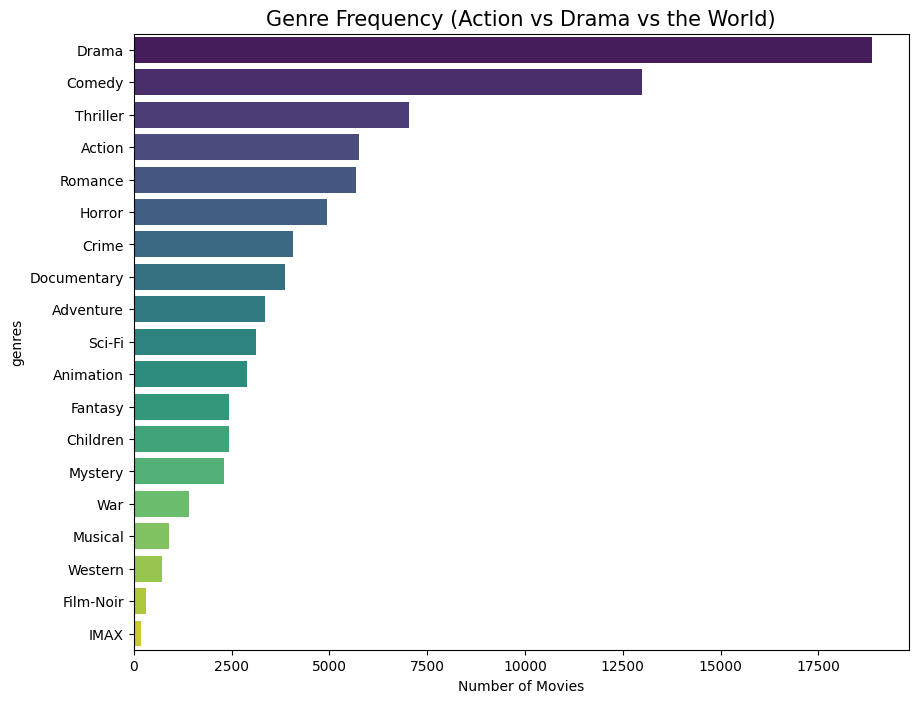

In [32]:
plt.figure(figsize=(10, 8))
genre_counts = (
    movies_df.select("genres")
    .with_columns(pl.col("genres").str.split("|"))
    .explode("genres")
    .filter(pl.col("genres") != "(no genres listed)")
    .group_by("genres")
    .len()
    .sort("len", descending=True)
)
sns.barplot(x="len", y="genres", data=genre_counts.to_pandas(), palette="viridis")
plt.title("Genre Frequency (Action vs Drama vs the World)", fontsize=15)
plt.xlabel("Number of Movies")

C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\1606383190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="len", data=rating_dist.to_pandas(), palette="coolwarm")


Text(0, 0.5, 'Count of Ratings')

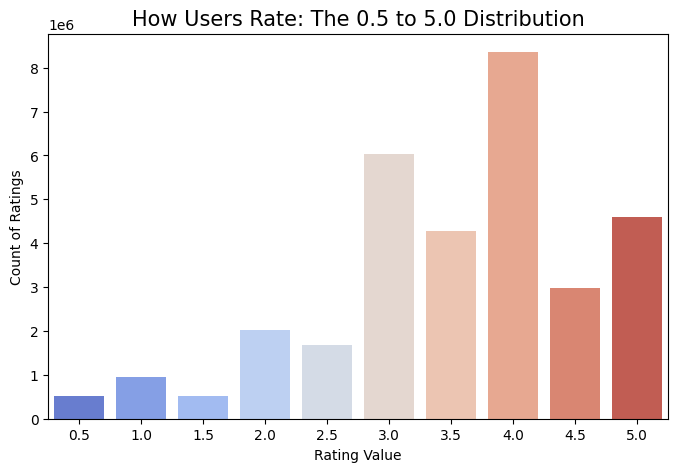

In [33]:
plt.figure(figsize=(8, 5))
rating_dist = ratings_df.group_by("rating").len().sort("rating")
sns.barplot(x="rating", y="len", data=rating_dist.to_pandas(), palette="coolwarm")
plt.title("How Users Rate: The 0.5 to 5.0 Distribution", fontsize=15)
plt.xlabel("Rating Value")
plt.ylabel("Count of Ratings")

C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\3100640232.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating_count", y="display_title", data=top_10.to_pandas(), palette="flare")


Text(0.5, 0, 'Total Number of Ratings')

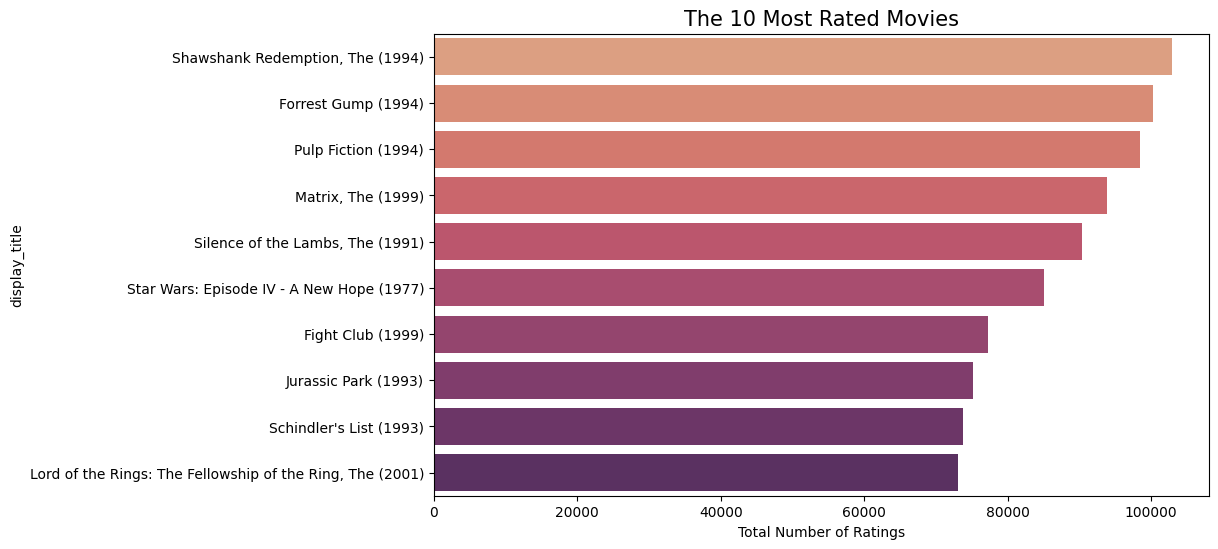

In [35]:
top_10 = (
    movie_stats.join(movies_df, on="movieId")
    .sort("rating_count", descending=True)
    .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x="rating_count", y="display_title", data=top_10.to_pandas(), palette="flare")
plt.title("The 10 Most Rated Movies", fontsize=15)
plt.xlabel("Total Number of Ratings")

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

# --- THE POST-CLEANING PIPELINE ---

# Stage 1: Encode Genres
print("Running Stage 1: Genre Encoding...")
unique_genres = [g for g in movies_df.select("genres").with_columns(pl.col("genres").str.split("|")).explode("genres").unique().sort("genres")["genres"].to_list() if g != "(no genres listed)"]
for genre in unique_genres:
    col_name = f"g_{genre.lower().replace(' ', '_').replace('-', '_')}"
    movies_df = movies_df.with_columns(pl.col("genres").str.contains(genre).cast(pl.Int8).alias(col_name))

# Stage 2: Scale Year
print("Running Stage 2: Year Scaling...")
min_y, max_y = movies_df.filter(pl.col("year") > 0)["year"].min(), movies_df["year"].max()
movies_df = movies_df.with_columns(((pl.col("year") - min_y) / (max_y - min_y)).clip(0, 1).alias("year_scaled"))

# Stage 3: Vectorize Tags
print("Running Stage 3: Tag Vectorization...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(movies_df["tag"].to_list())

# Stage 4: Master Feature Stack
print("Running Stage 4: Feature Stacking...")
feature_cols = [c for c in movies_df.columns if c.startswith("g_") or c == "year_scaled"]
genre_year_matrix = sp.csr_matrix(movies_df.select(feature_cols).to_numpy())
final_features = sp.hstack([genre_year_matrix, tfidf_matrix])

# Stage 5: Inference Function
def get_recommendations(target_title, n=5):
    try:
        idx = movies_df.select(pl.arg_where(pl.col("display_title") == target_title))[0,0]
        query_vec = final_features[idx]
        scores = cosine_similarity(query_vec, final_features).flatten()
        similar_indices = scores.argsort()[-(n+1):-1][::-1]
        return movies_df.with_columns(pl.Series("score", scores)).gather(similar_indices).select(["display_title", "genres", "score"])
    except:
        return "Movie not found. Use the format 'Movie Name (Year)'"

print("\n--- PIPELINE COMPLETE: READY FOR RECOMMENDATIONS ---")

Running Stage 1: Genre Encoding...
Running Stage 2: Year Scaling...
Running Stage 3: Tag Vectorization...
Running Stage 4: Feature Stacking...

--- PIPELINE COMPLETE: READY FOR RECOMMENDATIONS ---


In [19]:
# Use this to find the exact "display_title" if you are stuck
search_term = "Inception"
print(movies_df.filter(pl.col("display_title").str.contains(search_term)).select("display_title"))

shape: (1, 1)
┌──────────────────┐
│ display_title    │
│ ---              │
│ str              │
╞══════════════════╡
│ Inception (2010) │
└──────────────────┘


In [20]:
# Test the engine with Inception
inception_recs = get_recommendations("Inception (2010)")
print(inception_recs)

Movie not found. Use the format 'Movie Name (Year)'


In [24]:
def get_recommendations(target_title, n=5):
    target_title = target_title.strip()
    
    try:
        # 1. Find the index
        idx_series = movies_df.select(pl.arg_where(pl.col("display_title") == target_title))
        
        if idx_series.height == 0:
            return f"❌ '{target_title}' not found."
            
        idx = idx_series[0,0]
        
        # 2. Math: Cosine Similarity
        query_vec = final_features[idx]
        scores = cosine_similarity(query_vec, final_features).flatten()
        
        # 3. Get the top N indices (skipping the first one)
        similar_indices = scores.argsort()[-(n+1):-1][::-1]
        
        # 4. Create the result dataframe (Old-school indexing for compatibility)
        # We add the score and then grab only the similar rows
        temp_df = movies_df.with_columns(pl.Series("score", scores))
        return temp_df[similar_indices, :].select(["display_title", "genres", "score"])
        
    except Exception as e:
        return f"⚠️ An error occurred: {e}"

print("Engine Fixed & Compatible. Try it now!")

Engine Fixed & Compatible. Try it now!


In [25]:
get_recommendations("Inception (2010)")

display_title,genres,score
str,str,f64
"""Watchmen (2009)""","""Action|Drama|Mystery|Sci-Fi|Th…",0.862261
"""Strange Days (1995)""","""Action|Crime|Drama|Mystery|Sci…",0.847491
"""Third Man Out (2005)""","""Action|Crime|Drama|Mystery|Thr…",0.812563
"""Dying is Easy (2021)""","""Action|Crime|Drama|Mystery|Thr…",0.812313
"""Three Men to Destroy (1980)""","""Action|Crime|Drama|Mystery|Thr…",0.810063


In [39]:
# --- STEP 1: Search for your movie ---
my_search = "Forrest Gump"  # <--- CHANGE THIS to any movie name

# This finds the first movie that contains your search term
search_results = movies_df.filter(
    pl.col("display_title").str.contains("(?i)" + my_search) # (?i) makes it case-insensitive
).select("display_title")

if search_results.height > 0:
    target = search_results[0, 0]
    print(f"Targeting: {target}")
    print("-" * 30)
    
    # --- STEP 2: Get Recommendations ---
    recommendations = get_recommendations(target)
    print(recommendations)
else:
    print(f"No movie found containing '{my_search}'. Try a different word!")

Targeting: Forrest Gump (1994)
------------------------------
shape: (5, 3)
┌─────────────────────────────────┬──────────────────────────┬──────────┐
│ display_title                   ┆ genres                   ┆ score    │
│ ---                             ┆ ---                      ┆ ---      │
│ str                             ┆ str                      ┆ f64      │
╞═════════════════════════════════╪══════════════════════════╪══════════╡
│ Divine Intervention (Yadon ila… ┆ Comedy|Drama|Romance|War ┆ 0.906937 │
│ Life Is Beautiful (La Vita è b… ┆ Comedy|Drama|Romance|War ┆ 0.879819 │
│ Music Within (2007)             ┆ Comedy|Drama|Romance|War ┆ 0.846205 │
│ Tiger and the Snow, The (La ti… ┆ Comedy|Drama|Romance|War ┆ 0.845772 │
│ Their Finest (2017)             ┆ Comedy|Drama|Romance|War ┆ 0.841602 │
└─────────────────────────────────┴──────────────────────────┴──────────┘


In [ ]:
# 1. Load your clean movies and the links file
movies_df = pl.read_parquet("data/processed/movies_final.parquet")
links_df = pl.read_csv("data/raw/links.csv")

# 2. Merge them together
# We only need movieId and tmdbId
movies_with_links = movies_df.join(
    links_df.select(["movieId", "tmdbId"]), 
    on="movieId", 
    how="left"
)

# 3. Clean up: Drop any movies that don't have a TMDB ID (they won't have posters)
movies_with_links = movies_with_links.drop_nulls(subset=["tmdbId"])

# 4. Save this as the final version for the app
movies_with_links.write_parquet("data/processed/movies_featurized.parquet")

print(f"Success! {movies_with_links.height} movies now have TMDB IDs attached.")